In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import  matplotlib.pyplot as plt

In [2]:
# import the data we gonna work on
df_train = pd.read_csv('train_kaggle.csv')
df_test = pd.read_csv('test_kaggle.csv')

In [29]:
df_train

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984
...,...,...
695,58.0,58.595006
696,93.0,94.625094
697,82.0,88.603770
698,66.0,63.648685


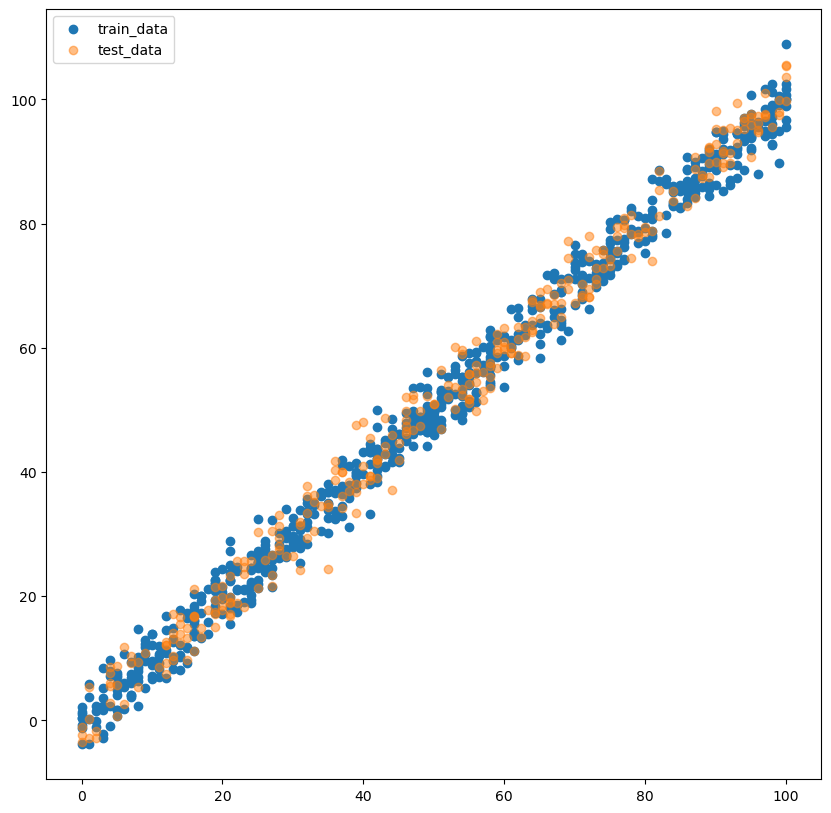

In [37]:
# let us plot the data
plt.figure(figsize=(10,10))
plt.scatter(df_train.x , df_train.y,label='train_data')
plt.scatter(df_test.x, df_test.y , alpha=0.5,label='test_data')
plt.legend()
plt.show()

`This looks pretty heavy linear`

In [3]:
print(df_train.info())
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       300 non-null    int64  
 1   y       300 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 4.8 KB
None


In [10]:
df_train = df_train.dropna()

In [11]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 699 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       699 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 16.4 KB


In [12]:
# We will seperate x and y for both train df  and test df
x_train = df_train.iloc[:,0:1]
y_train = df_train.iloc[:,-1]
x_test = df_test.iloc[:,0:1]
y_test = df_test.iloc[:,-1]

`This is done this way since we need A dataframe for x values and a Series for y values`

In [15]:
lr = LinearRegression()

In [16]:
lr.fit(x_train,y_train)

LinearRegression()

`Values of Weightage and y-intercept`

In [25]:
m = lr.coef_
b = lr.intercept_
print(f"Weightage ->{m[0]}, y-intercept ->{b}")

Weightage ->1.000656381856304, y-intercept ->-0.10726546430097272


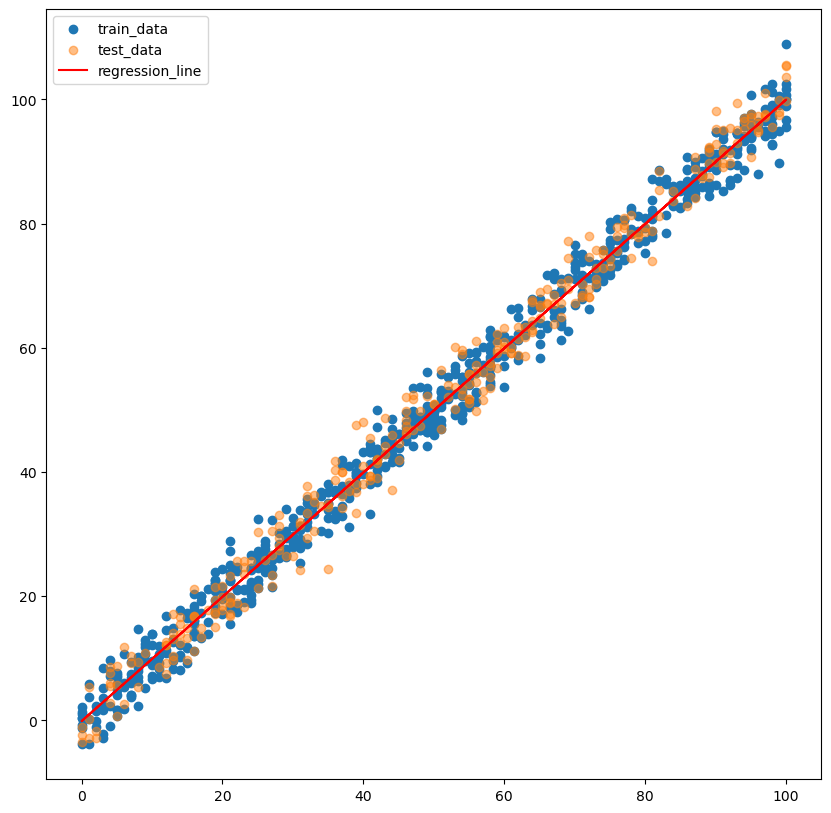

In [63]:
# Plot the scatter for data along with the linear regression fitted line on trained data
plt.figure(figsize=(10,10))
plt.scatter(df_train.x , df_train.y,label='train_data')
plt.scatter(df_test.x, df_test.y , alpha=0.5,label='test_data')
plt.plot(df_train.x , lr.predict(df_train[['x']]),color='red',label='regression_line')
plt.legend()
plt.show()

In [42]:
predicted_data = lr.predict(df_test[['x']])

In [ ]:
predicted_data[:10] #This is our predicted data

array([76.94327594, 20.90651855, 21.90717494, 19.90586217, 35.91636428,
       14.90258026, 61.93343021, 94.95509081, 19.90586217,  4.89601644])

In [50]:
# Let us find MAE AND RMSE 
mae = np.mean(np.abs(df_test.x.values - predicted_data))
rmse = np.sqrt(np.mean((df_test.x.values - predicted_data)**2))

In [51]:
print(f"Mean Absolute Error(MAE) = {mae} \nRoot Mean Squared Error(RMSE) = {rmse}")

Mean Absolute Error(MAE) = 0.07383156048037276 
Root Mean Squared Error(RMSE) = 0.07615763391461461


`We see that our data is fitted very nicely the error is less than 1%`

In [59]:
# Automatic Error using library
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [60]:
print(mean_absolute_error(df_test.x.values, predicted_data))
print(root_mean_squared_error(df_test.x.values, predicted_data))
print(r2_score(df_test.x.values, predicted_data))

0.07383156048037276
0.07615763391461461
0.999992837632062


`r2 score of almost 1 tells us that y parameter depends only on x parameter`

In [55]:
df_test['pred_y'] = predicted_data

In [57]:
df_test

,x,y,pred_y
0,77,79.775152,76.943276
1,21,23.177279,20.906519
2,22,25.609262,21.907175
3,20,17.857388,19.905862
4,36,41.849864,35.916364
...,...,...,...
295,71,68.545888,70.939338
296,46,47.334876,45.922928
297,55,54.090637,54.928836
298,62,63.297171,61.933430
